## Modeling the agent
1. Feature selection: remove the columns I will not use (for example, the indexing, lat, longitude, and name of the station)
2. Train the models with resampling
3. .....


### Libraries and tools to ues




### Preparation of the venvironment (as on the other notebooks)

In [6]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

# Make src/ importable: add the project root (parent of notebooks/) to sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Run from the project root so relative paths like "data/raw/..." resolve
os.chdir(project_root)
print(f"Working dir: {os.getcwd()}")

from src.model import *

import pandas as pd

# Start by importing the data
train_path = Path('data/processed/cleaned_data.csv')
df_train = pd.read_csv(train_path)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Working dir: c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting


### Feature selection

In [7]:
# Split the features
x_train, y_train = prepare_features(df_train)
#print(X_train)

In [ ]:
featurce_performance = feature_selection_report(x_train,y_train)

print("features:", featurce_performance)
print("train data shape:", x_train.shape)


In [ ]:
x_train

### Benchmarking different methods

In [8]:
#I first need to create all the models that I will asses
model_grid = get_model_grid()

In [9]:
#Then i train them with the default folds
results = benchmark_models(X=x_train,y=y_train,models=model_grid,sample_size=200_000)

c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Featureless fold 1/3: RMSE=9.886  MAE=7.731 RMSLE=1.010
  Featureless fold 2/3: RMSE=8.842  MAE=6.963 RMSLE=0.890
  Featureless fold 3/3: RMSE=9.113  MAE=7.227 RMSLE=0.915
  decision_tree fold 1/3: RMSE=7.452  MAE=5.590 RMSLE=0.751
  decision_tree fold 2/3: RMSE=7.019  MAE=5.429 RMSLE=0.744
  decision_tree fold 3/3: RMSE=6.528  MAE=4.848 RMSLE=0.674
  random_forest fold 1/3: RMSE=7.410  MAE=5.579 RMSLE=0.747
  random_forest fold 2/3: RMSE=6.940  MAE=5.337 RMSLE=0.733
  random_forest fold 3/3: RMSE=6.481  MAE=4.816 RMSLE=0.671
  hist_gbm fold 1/3: RMSE=7.119  MAE=5.419 RMSLE=0.714
  hist_gbm fold 2/3: RMSE=6.601  MAE=5.170 RMSLE=0.725
  hist_gbm fold 3/3: RMSE=6.450  MAE=4.998 RMSLE=0.692
  xgboost fold 1/3: RMSE=7.196  MAE=5.494 RMSLE=0.730
  xgboost fold 2/3: RMSE=6.638  MAE=5.178 RMSLE=0.729
  xgboost fold 3/3: RMSE=6.355  MAE=4.892 RMSLE=0.687
  lightgbm fold 1/3: RMSE=7.110  MAE=5.382 RMSLE=0.707
  lightgbm fold 2/3: RMSE=6.598  MAE=5.135 RMSLE=0.726
  lightgbm fold 3/3: RMSE=6.3

In [10]:
print(results)

           model  mean_rmse  std_rmse  mean_mae  mean_rmsle  std_rmsle  \
0       lightgbm   6.695999  0.305720  5.155181    0.706661   0.015705   
1       hist_gbm   6.723266  0.286831  5.195994    0.710649   0.013713   
2        xgboost   6.729858  0.349496  5.187902    0.715055   0.020195   
3  random_forest   6.943783  0.379161  5.243897    0.717175   0.032790   
4  decision_tree   6.999456  0.377730  5.289276    0.723071   0.035083   
5    Featureless   9.280465  0.442480  7.306835    0.938110   0.051637   

   mean_poisson_deviance                                      rmse_per_fold  \
0               4.115836  [7.109586112683821, 6.598322080552823, 6.38008...   
1               4.089960  [7.119443508972913, 6.600607893519253, 6.44974...   
2               4.139672  [7.1964610091285985, 6.637742078716561, 6.3553...   
3               4.707649  [7.410079325679985, 6.939917189711687, 6.48135...   
4               4.837153  [7.45219739739286, 7.018623093533863, 6.527546...   
5      

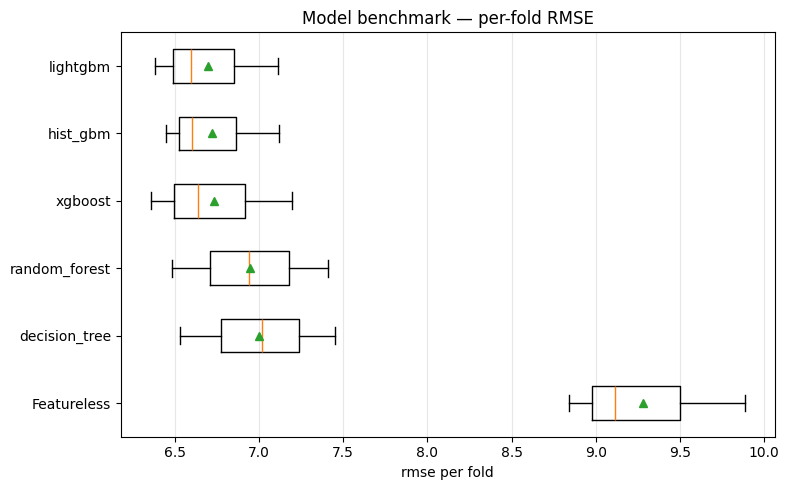

In [11]:
#Finally we print to see the higher performing
from src.model import plot_benchmark

fig, ax = plot_benchmark(results)

#### Now we train a model

In [ ]:
# check the featureless
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

print(y_pred)

In [ ]:
# This is a basic DecisionTreeRegressor, check if everything is working propperly, look into and crete a benchmark to determine if it improves with respect to a featureless learner.

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_squared_log_error
import numpy as np
import joblib

# Initialize — set max_depth to keep it interpretable and avoid overfitting
model = DecisionTreeRegressor(
    max_depth=20,        # decision tree depth
    min_samples_leaf=10, # minimum observations per leaf
    random_state=42,
)

# Train
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
# Predict
y_pred = model.predict(X_test)

print(y_pred)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
print(f"MAE:   {mae:.3f}")
print(f"RMSE:  {rmse:.3f}")
print(f"RMSLE: {rmsle:.3f}")

In [ ]:
# Save the model
joblib.dump(model, 'models/decision_tree_v1.joblib')